### Quick Start

The `LANfactory` package is a light-weight convenience package for training `likelihood approximation networks` (LANs) in PyTorch (or JAX/Flax), 
starting from supplied training data.

[LANs](https://elifesciences.org/articles/65074), although more general in potential scope of applications, were conceived in the context of sequential sampling modeling
to account for cognitive processes giving rise to *choice* and *reaction time* data in *n-alternative forced choice experiments* commonly encountered in the cognitive sciences.

In this quick tutorial we will use the [`ssms`](https://github.com/AlexanderFengler/ssm_simulators) package to generate our training data using such a sequential sampling model (SSM). The use of of the `LANfactory` package is in no way bound to utilize this `ssms` package.

#### Install

To install the `ssms` package type,

`pip install git+https://github.com/AlexanderFengler/ssm_simulators`

To install the `LANfactory` package type,

`pip install git+https://github.com/AlexanderFengler/LANfactory`

Necessary dependency should be installed automatically in the process.

#### Basic Tutorial

In [1]:
# Load necessary packages
import ssms
import lanfactory
import os
import numpy as np
from copy import deepcopy
import torch
from pathlib import Path

#### Generate Training Data
First we need to generate some training data. As mentioned above we will do so using the `ssms` python package, however without delving into a detailed explanation
of this package. Please refer to the [basic ssms tutorial] (https://github.com/AlexanderFengler/ssm_simulators) in case you want to learn more.

In [2]:
# MAKE CONFIGS
RUN_SIMS = True
DEVICE = "cpu"

# Define a model
MODEL = "ddm"
OUT_FOLDER = Path("torch_nb_data") / "lan" / "training_data"
MODEL_FOLDER = Path("torch_nb_data") / "torch_models" / "lan"
N_DATA_FILES = 2
BATCH_SIZE = 1000
os.makedirs(OUT_FOLDER, exist_ok=True)

# Initialize the generator config (nested config object from ssm-simulators)
generator_config = ssms.config.get_default_generator_config("lan")
# Generative model (any key from ssms.config.model_config)
generator_config["model"] = MODEL
# Number of parameter sets to simulate
generator_config["pipeline"]["n_parameter_sets"] = 100
# Generate data single-process inside the notebook
generator_config["pipeline"]["n_cpus"] = 1
# Simulation samples per parameter set
generator_config["simulator"]["n_samples"] = 200
# Training rows emitted per parameter set
generator_config["training"]["n_samples_per_param"] = 200
# Folder to save generated data into
generator_config["output"]["folder"] = str(OUT_FOLDER)

# Make model config dict
model_config = deepcopy(ssms.config.model_config[MODEL])

In [3]:
# MAKE DATA
if RUN_SIMS:
    for i in range(N_DATA_FILES):
        print(f"Generating data file {i + 1} / {N_DATA_FILES}")
        my_dataset_generator = ssms.dataset_generators.lan_mlp.TrainingDataGenerator(
            config=generator_config, model_config=model_config
        )
        _ = my_dataset_generator.generate_data_training(save=True)

Generating data file 1 / 2


Generating data file 2 / 2


#### Prepare for Training

Now we define two configuration dictionariers,

1. The `network_config` dictionary defines the architecture and properties of the network
2. The `train_config` dictionary defines properties concerning training hyperparameters

Two examples (which we take as provided by the package, but which you can adjust according to your needs) are provided below.

In [4]:
# SPECIFY NETWORK CONFIGS AND TRAINING CONFIGS

network_config = deepcopy(lanfactory.config.network_configs.network_config_mlp)
network_config["layer_sizes"] = [100, 100, 100, 1]
network_config["activations"] = ["tanh", "tanh", "tanh", "linear"]

print("Network config: ")
print(network_config)

train_config = deepcopy(lanfactory.config.network_configs.train_config_mlp)
train_config["cpu_batch_size"] = 4096
train_config["gpu_batch_size"] = 4096
train_config["learning_rate"] = 1e-3

print("Train config: ")
print(train_config)

Network config: 
{'layer_sizes': [100, 100, 100, 1], 'activations': ['tanh', 'tanh', 'tanh', 'linear'], 'train_output_type': 'logprob'}
Train config: 
{'cpu_batch_size': 4096, 'gpu_batch_size': 4096, 'n_epochs': 5, 'optimizer': 'adam', 'learning_rate': 0.001, 'lr_scheduler': 'reduce_on_plateau', 'lr_scheduler_params': {}, 'weight_decay': 0.0, 'loss': 'huber', 'save_history': True}


Next we set up dataloaders for training with pytorch. The `LANfactory` provides convenient helper functions for this.

The `make_train_valid_dataloaders` function handles:
- Splitting your data files into training and validation sets
- Creating the appropriate `DatasetTorch` objects
- Wrapping them in PyTorch `DataLoader` objects with sensible defaults

Under the hood, this uses the `DatasetTorch` class which handles batching and file loading internally.

In [5]:
# MAKE DATALOADERS

# Data files were generated directly into OUT_FOLDER above
file_list_ = list(Path(OUT_FOLDER).glob("*.pickle"))

# num_workers=0 keeps data loading in-process: ssm-simulators sets the
# multiprocessing start method to "spawn" at import, which is unsafe for
# DataLoader worker processes inside a notebook.
torch_training_dataloader, torch_validation_dataloader, input_dim = lanfactory.trainers.make_train_valid_dataloaders(
    file_ids=file_list_,
    batch_size=BATCH_SIZE,
    network_type="lan",
    train_val_split=0.5,
    num_workers=0,
    pin_memory=False,
)

print(f"Training batches: {len(torch_training_dataloader)}")
print(f"Validation batches: {len(torch_validation_dataloader)}")
print(f"Input dimension: {input_dim}")

Training batches: 60
Validation batches: 60
Input dimension: 6


We can now load a network, and save the configuration files for convenience.

In [6]:
# LOAD NETWORK
# Option 1: Using the factory function (recommended)
net = lanfactory.trainers.TorchMLPFactory(
    network_config=deepcopy(network_config),
    input_dim=input_dim,
    network_type="lan",
)

# Option 2: Direct instantiation (also works)
# net = lanfactory.trainers.TorchMLP(
#     network_config=deepcopy(network_config),
#     input_shape=input_dim,
#     network_type="lan",
# )

# SAVE CONFIGS
lanfactory.utils.save_configs(
    model_id=MODEL + "_torch_",
    save_folder=str(Path("torch_nb_data/torch_models/lan/" + MODEL + "/")),
    network_config=network_config,
    train_config=train_config,
)

tanh
tanh
tanh
linear
Saved network config
Saved train config


### Architecture

Quick look at the simple MLP architecture of the network.

In [7]:
print(net)

TorchMLP(
  (layers): ModuleList(
    (0): Linear(in_features=6, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): Tanh()
    (6): Linear(in_features=100, out_features=1, bias=True)
  )
)


To finally train the network we supply our network, the dataloaders and training config to the `ModelTrainerTorchMLP` class, from `lanfactory.trainers`.

In [8]:
# TRAIN MODEL
model_trainer = lanfactory.trainers.ModelTrainerTorchMLP(
    model=net,
    train_config=train_config,
    train_dl=torch_training_dataloader,
    valid_dl=torch_validation_dataloader,
    allow_abs_path_folder_generation=False,
    pin_memory=False,
    seed=None,
)

# model_trainer.train_model(save_history=True, save_model=True, verbose=0)
model_trainer.train_and_evaluate(
    mlflow_on=False,
    output_folder=Path("torch_nb_data/torch_models/" + MODEL + "_lan" + "/"),
    output_file_id=MODEL,
)
# LOAD MODEL

train_config is passed as dictionary: 

{'cpu_batch_size': 4096, 'gpu_batch_size': 4096, 'n_epochs': 5, 'optimizer': 'adam', 'learning_rate': 0.001, 'lr_scheduler': 'reduce_on_plateau', 'lr_scheduler_params': {}, 'weight_decay': 0.0, 'loss': 'huber', 'save_history': True}


epoch: 0/5, batch: 0/60, batch_loss: 4.0360
Epoch took 0 / 5, took 0.06577801704406738 seconds
epoch 0 / 5, validation_loss: 3.501
epoch: 1/5, batch: 0/60, batch_loss: 3.3705
Epoch took 1 / 5, took 0.051306962966918945 seconds
epoch 1 / 5, validation_loss: 2.666
epoch: 2/5, batch: 0/60, batch_loss: 2.6298
Epoch took 2 / 5, took 0.049957275390625 seconds


epoch 2 / 5, validation_loss: 1.525
epoch: 3/5, batch: 0/60, batch_loss: 1.3605
Epoch took 3 / 5, took 0.051458120346069336 seconds
epoch 3 / 5, validation_loss: 1.015
epoch: 4/5, batch: 0/60, batch_loss: 0.9710
Epoch took 4 / 5, took 0.050015926361083984 seconds
epoch 4 / 5, validation_loss: 0.8927


#### Load Model for Inference and Call

The `LANfactory` provides some convenience functions to use networks for inference after training. 
We can load a model using the `LoadTorchMLPInfer` class, which then allows us to run fast inference via either
a direct call, which expects a `torch.tensor` as input, or the `predict_on_batch` method, which expects a `numpy.array` 
of `dtype`, `np.float32`. 

In [9]:
model_path = Path("torch_nb_data/torch_models") / (MODEL + "_lan")
network_file_path = next(model_path.glob("*state_dict*"))

# LoadTorchMLPInfer automatically calls eval() for inference mode
network = lanfactory.trainers.LoadTorchMLPInfer(
    model_file_path=network_file_path,
    network_config=network_config,
    input_dim=input_dim,
)

Setting network type to "lan" or "cpn" based on train_output_type. 
Note: This is only a default setting, and can be overwritten by the network_type argument.
tanh
tanh
tanh
linear


In [10]:
# Two ways to call the network

# Direct call --> need tensor input
direct_out = network(
    torch.from_numpy(np.array(ssms.config.model_config[MODEL]['default_params'] + [0.65, 1.0], dtype=np.float32))
)
print("direct call out: ", direct_out)

# predict_on_batch method
predict_on_batch_out = network.predict_on_batch(
    np.array(ssms.config.model_config[MODEL]['default_params'] + [0.65, 1.0], dtype=np.float32)
)
print("predict_on_batch out: ", predict_on_batch_out)

direct call out:  tensor([-0.5359])
predict_on_batch out:  [-0.53591543]


#### A peek into the first passage distribution computed by the network

We can compare the learned likelihood function in our `network` with simulation data from the underlying generative model.
For this purpose we recruit the [`ssms`](https://github.com/AlexanderFengler/ssm_simulators) package again.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Data
data = pd.DataFrame(
    np.zeros((2000, len(ssms.config.model_config[MODEL]['params']) + 2), dtype=np.float32),
    columns=ssms.config.model_config[MODEL]['params'] + ["rt", "choice"],
)

# Set parameters
for i, param in enumerate(ssms.config.model_config[MODEL]['params']):
    data.loc[:, param] = np.float32(ssms.config.model_config[MODEL]['default_params'][i])

# Set rt and choice
data.loc[:999, "rt"] = np.linspace(5, 0, 1000).astype(np.float32)
data.loc[1000:, "rt"] = np.linspace(0, 5, 1000).astype(np.float32)
data.loc[:999, "choice"] = -1.
data.loc[1000:, "choice"] = 1.

# Network predictions
predict_on_batch_out = network.predict_on_batch(data.values.astype(np.float32))

# Simulations
from ssms.basic_simulators.simulator import simulator

sim_out = {}
for i in range(10):
    sim_out[i] = simulator(model=MODEL, theta=data.values[0, :-2], n_samples=2000)

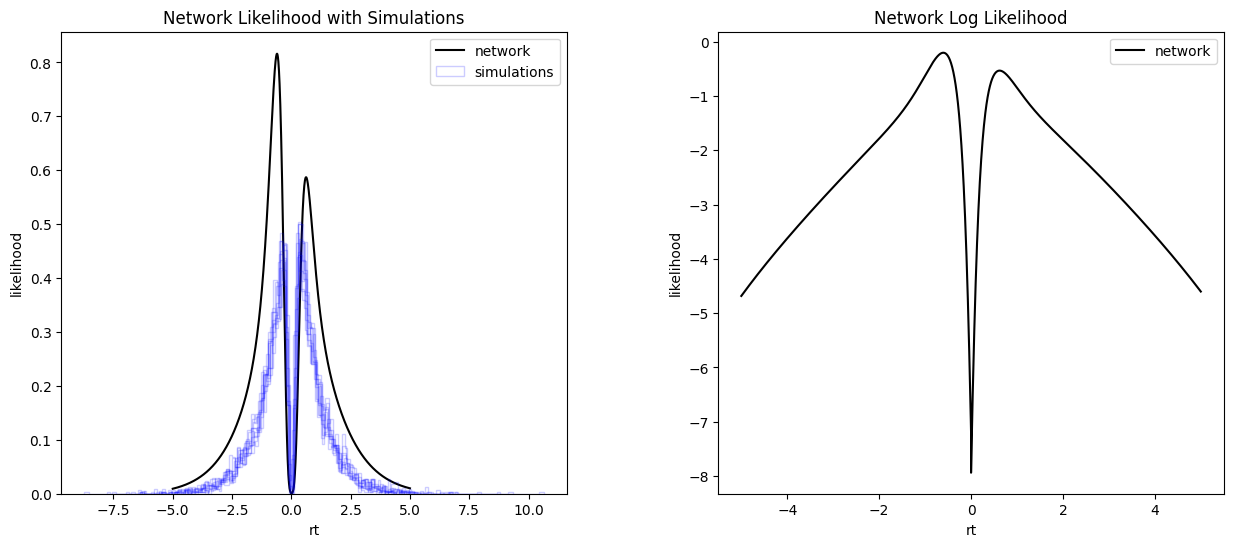

In [12]:
import matplotlib.pyplot as plt

# Create figure with specific spacing
fig = plt.figure(figsize=(15, 6))

# First subplot
ax1 = plt.subplot(1, 2, 1)
ax1.plot(
    data["rt"] * data["choice"],
    np.exp(predict_on_batch_out),
    color="black",
    label="network",
)

# Plot simulations
for i in range(10):
    my_seed = np.random.choice(1000000)
    sim_out = simulator(
        model=MODEL, 
        theta=data.values[0, :-2], 
        n_samples=2000, 
        random_state=my_seed
    )
    ax1.hist(
        sim_out["rts"] * sim_out["choices"],
        bins=100,
        histtype="step",
        label="simulations" if i == 0 else None,
        color="blue",
        alpha=0.2,
        density=True,
    )

ax1.legend()
ax1.set_title("Network Likelihood with Simulations")
ax1.set_xlabel("rt")
ax1.set_ylabel("likelihood")

# Second subplot
ax2 = plt.subplot(1, 2, 2)
ax2.plot(
    data["rt"] * data["choice"],
    predict_on_batch_out,
    color="black",
    label="network",
)

ax2.legend()
ax2.set_title("Network Log Likelihood")
ax2.set_xlabel("rt")
ax2.set_ylabel("likelihood")

# Adjust spacing
plt.subplots_adjust(wspace=0.3)
plt.show()

We hope this package may be helpful in case you attempt to train [LANs](https://elifesciences.org/articles/65074) for your own research.

#### END